# Статистическая проверка гипотезы. MILP vs Эвристики (Avalanche, Snowball).

Данный ноутбук предназначен для анализа результатов вычислительного эксперимента. 
Предполагается, что прогоны алгоритмов уже выполнены, а результаты сохранены в табличном виде (например, CSV).

**Формулировка гипотезы:**
Если реализовать и корректно верифицировать MILP-модель задачи RPML, то на сопоставимых инстансах суммарные затраты на погашение долгов будут систематически ниже, чем при использовании эвристик Debt Avalanche и Debt Snowball.

**Нулевая гипотеза ($H_0$):** медианная разность затрат равна нулю (MILP не дает улучшений).
**Альтернативная гипотеза ($H_1$):** медианная разность меньше нуля (MILP дает строго меньшие суммарные затраты).

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

## 1. Загрузка и подготовка данных

Ожидается источник результатов из run-каталога или legacy-файла. Подходят checkpoint JSONL и CSV с колонками `instance_name`, `milp_cost`, `avalanche_cost`, `snowball_cost`, `status`.
Для корректного сравнения фильтруем только те инстансы, где MILP нашел глобальный оптимум (`OPTIMAL`).

Сначала выберите run в виджете ниже, затем заново выполните аналитические ячейки под ним.

In [2]:
import json

RUNS_ROOT = Path("./tmp/runs")
LEGACY_CHECKPOINT_PATH = Path("./tmp/experiment_results_checkpoint.jsonl")
LEGACY_DATA_PATH = Path("./tmp/experiment_results.csv")
RUN_ID = None


def _load_json_file(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return None


def _result_artifact_mtime(run_dir: Path) -> float:
    candidates = [
        run_dir / "checkpoint" / "experiment_results_checkpoint.jsonl",
        run_dir / "checkpoint" / "monte_carlo_experiment_results_checkpoint.jsonl",
        run_dir / "exports" / "experiment_results.csv",
        run_dir / "exports" / "monte_carlo_experiment_results.csv",
        run_dir / "monte_carlo" / "mc_income_results.csv",
        run_dir / "monte_carlo" / "mc_income_results_meta.json",
        run_dir / "run_state.json",
        run_dir / "run_config.json",
    ]
    mtimes = [path.stat().st_mtime for path in candidates if path.exists()]
    return max(mtimes) if mtimes else 0.0


def resolve_run_dir(runs_root: Path, run_id: str | None = None) -> Path | None:
    if run_id:
        run_dir = runs_root / run_id
        if not run_dir.exists():
            raise FileNotFoundError(f"Run directory not found: {run_dir}")
        return run_dir

    if not runs_root.exists():
        return None

    candidates: list[Path] = []
    for run_dir in runs_root.iterdir():
        if not run_dir.is_dir():
            continue
        if _result_artifact_mtime(run_dir) > 0.0:
            candidates.append(run_dir)

    if not candidates:
        return None

    def sort_key(run_dir: Path) -> tuple[int, float]:
        state = _load_json_file(run_dir / "run_state.json") or {}
        status = str(state.get("status", "")).lower()
        status_rank = {"completed": 3, "running": 2, "interrupted": 1}.get(status, 0)
        return status_rank, _result_artifact_mtime(run_dir)

    return max(candidates, key=sort_key)


def resolve_results_path(run_dir: Path | None) -> Path:
    if run_dir is not None:
        state = _load_json_file(run_dir / "run_config.json") or {}
        cli_args = state.get("cli_args") or {}
        mc_enabled = bool(cli_args.get("mc_income"))
        preferred_paths = [
            run_dir / "checkpoint" / (
                "monte_carlo_experiment_results_checkpoint.jsonl" if mc_enabled else "experiment_results_checkpoint.jsonl"
            ),
            run_dir / "exports" / (
                "monte_carlo_experiment_results.csv" if mc_enabled else "experiment_results.csv"
            ),
            run_dir / "checkpoint" / (
                "experiment_results_checkpoint.jsonl" if mc_enabled else "monte_carlo_experiment_results_checkpoint.jsonl"
            ),
            run_dir / "exports" / (
                "experiment_results.csv" if mc_enabled else "monte_carlo_experiment_results.csv"
            ),
        ]
        for path in preferred_paths:
            if path.exists():
                return path
        raise FileNotFoundError(f"No supported results artifacts found in {run_dir}")

    for path in (LEGACY_CHECKPOINT_PATH, LEGACY_DATA_PATH):
        if path.exists():
            return path

    raise FileNotFoundError(
        f"No results found. Checked {LEGACY_CHECKPOINT_PATH}, {LEGACY_DATA_PATH}, and tmp/runs."
    )


def load_results_frame(path: Path) -> pd.DataFrame:
    if path.suffix == ".jsonl":
        records: list[dict] = []
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                records.append(json.loads(line))
        if not records:
            raise ValueError(f"No records found in {path}")
        df_local = pd.DataFrame(records)
        if "instance_name" in df_local.columns and "instance" not in df_local.columns:
            df_local["instance"] = df_local["instance_name"]
        if "optimal_cost" in df_local.columns and "milp_cost" not in df_local.columns:
            df_local["milp_cost"] = df_local["optimal_cost"]
        if "optimal_status" in df_local.columns and "status" not in df_local.columns:
            df_local["status"] = df_local["optimal_status"]
        if "optimal_solve_time" in df_local.columns and "solve_time" not in df_local.columns:
            df_local["solve_time"] = df_local["optimal_solve_time"]
        if "optimal_gap" in df_local.columns and "gap" not in df_local.columns:
            df_local["gap"] = df_local["optimal_gap"]
        return df_local
    return pd.read_csv(path)


RUN_DIR = resolve_run_dir(RUNS_ROOT, RUN_ID)
DATA_PATH = resolve_results_path(RUN_DIR)

df = load_results_frame(DATA_PATH)
if "status" not in df.columns:
    raise KeyError(f"Required column 'status' is missing in {DATA_PATH}")
if "milp_cost" not in df.columns:
    raise KeyError(f"Required column 'milp_cost' is missing in {DATA_PATH}")
if "avalanche_cost" not in df.columns or "snowball_cost" not in df.columns:
    raise KeyError(f"Baseline cost columns are missing in {DATA_PATH}")

df_opt = df[df['status'] == 'OPTIMAL'].copy()
print(f"Всего инстансов: {len(df)}")
print(f"Инстансов со статусом OPTIMAL: {len(df_opt)}")
if RUN_DIR is None:
    print(f"Используется legacy файл: {DATA_PATH}")
else:
    print(f"Используется run: {RUN_DIR.name}")
    print(f"Источник данных: {DATA_PATH}")

# Отрицательное значение означает, что MILP выгоднее (затраты меньше)
df_opt['delta_avalanche'] = df_opt['milp_cost'] - df_opt['avalanche_cost']
df_opt['delta_snowball'] = df_opt['milp_cost'] - df_opt['snowball_cost']

Всего инстансов: 11000
Инстансов со статусом OPTIMAL: 11000
Используется run: 20260331-161458_ru_mc_n4_tl300_sc100_seed42_647369ff
Источник данных: tmp/runs/20260331-161458_ru_mc_n4_tl300_sc100_seed42_647369ff/checkpoint/monte_carlo_experiment_results_checkpoint.jsonl


In [3]:
try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("Для выбора run в ноутбуке нужен пакет ipywidgets") from exc

from IPython.display import clear_output, display


def _run_sort_key(run_dir: Path) -> tuple[int, float]:
    state = _load_json_file(run_dir / "run_state.json") or {}
    status = str(state.get("status", "")).lower()
    status_rank = {"completed": 3, "running": 2, "interrupted": 1}.get(status, 0)
    return status_rank, _result_artifact_mtime(run_dir)


def _run_display_label(run_dir: Path) -> str:
    state = _load_json_file(run_dir / "run_state.json") or {}
    config = _load_json_file(run_dir / "run_config.json") or {}
    cli_args = config.get("cli_args") or {}
    mc_enabled = bool(cli_args.get("mc_income")) or (run_dir / "monte_carlo" / "mc_income_results.csv").exists()
    status = str(state.get("status", "unknown"))
    mode = "MC" if mc_enabled else "STD"
    return f"{run_dir.name} [{status}, {mode}]"


def _available_run_options() -> list[tuple[str, str]]:
    options: list[tuple[str, str]] = [
        ("Авто: последний доступный run", "__latest__"),
        ("Legacy tmp/experiment_results.csv", "__legacy__"),
    ]
    if RUNS_ROOT.exists():
        run_dirs = [
            run_dir
            for run_dir in RUNS_ROOT.iterdir()
            if run_dir.is_dir() and _result_artifact_mtime(run_dir) > 0.0
        ]
        run_dirs.sort(key=_run_sort_key, reverse=True)
        options.extend((_run_display_label(run_dir), run_dir.name) for run_dir in run_dirs)
    return options


def _load_active_run(choice: str) -> None:
    global RUN_ID, RUN_DIR, DATA_PATH, df, df_opt

    if choice == "__legacy__":
        RUN_ID = None
        RUN_DIR = None
        DATA_PATH = resolve_results_path(None)
    else:
        resolved_run_dir = resolve_run_dir(RUNS_ROOT, None if choice == "__latest__" else choice)
        if resolved_run_dir is None:
            RUN_ID = None
            RUN_DIR = None
            DATA_PATH = resolve_results_path(None)
        else:
            RUN_ID = resolved_run_dir.name
            RUN_DIR = resolved_run_dir
            DATA_PATH = resolve_results_path(resolved_run_dir)

    df = load_results_frame(DATA_PATH)
    if "status" not in df.columns:
        raise KeyError(f"Required column 'status' is missing in {DATA_PATH}")
    if "milp_cost" not in df.columns:
        raise KeyError(f"Required column 'milp_cost' is missing in {DATA_PATH}")
    if "avalanche_cost" not in df.columns or "snowball_cost" not in df.columns:
        raise KeyError(f"Baseline cost columns are missing in {DATA_PATH}")

    df_opt = df[df["status"] == "OPTIMAL"].copy()
    df_opt["delta_avalanche"] = df_opt["milp_cost"] - df_opt["avalanche_cost"]
    df_opt["delta_snowball"] = df_opt["milp_cost"] - df_opt["snowball_cost"]


run_options = _available_run_options()
default_run_value = "__latest__" if any(option_id not in {"__latest__", "__legacy__"} for _, option_id in run_options) else "__legacy__"

run_selector = widgets.Dropdown(
    options=run_options,
    value=default_run_value,
    description="Run:",
    layout=widgets.Layout(width="900px"),
)
load_run_button = widgets.Button(description="Загрузить run", button_style="primary")
run_output = widgets.Output()


def _render_selected_run(_=None) -> None:
    with run_output:
        clear_output(wait=True)
        try:
            _load_active_run(run_selector.value)
            print(f"Всего инстансов: {len(df)}")
            print(f"Инстансов со статусом OPTIMAL: {len(df_opt)}")
            if RUN_DIR is None:
                print(f"Используется legacy источник: {DATA_PATH}")
            else:
                print(f"Используется run: {RUN_DIR.name}")
                print(f"Источник данных: {DATA_PATH}")
            print("После смены run перезапустите аналитические ячейки ниже.")
        except Exception as exc:
            print(f"Ошибка загрузки run: {exc}")
            raise


load_run_button.on_click(_render_selected_run)
run_selector.observe(lambda change: _render_selected_run() if change["name"] == "value" else None, names="value")
display(widgets.VBox([widgets.HBox([run_selector, load_run_button]), run_output]))
_render_selected_run()

## 2. Описательная статистика

Анализ базовых метрик распределения разностей.

In [4]:
summary_stats = pd.DataFrame({
    'MILP vs Avalanche': df_opt['delta_avalanche'].describe(),
    'MILP vs Snowball': df_opt['delta_snowball'].describe()
}).T

display(summary_stats.round(2))

,count,mean,std,min,25%,50%,75%,max
MILP vs Avalanche,11000.0,-252772.76,387954.81,-3979509.13,-371979.55,-58280.92,-16559.81,93890.1
MILP vs Snowball,11000.0,-291666.94,449595.27,-3149138.74,-343358.65,-79045.42,-25755.28,73811.8


## 3. Визуальный анализ

### 3.1 Диаграмма рассеяния (Scatter Plot)
Сравнение абсолютных значений затрат. Линия $Y = X$ обозначает равенство методов. Точки ниже линии означают превосходство MILP.

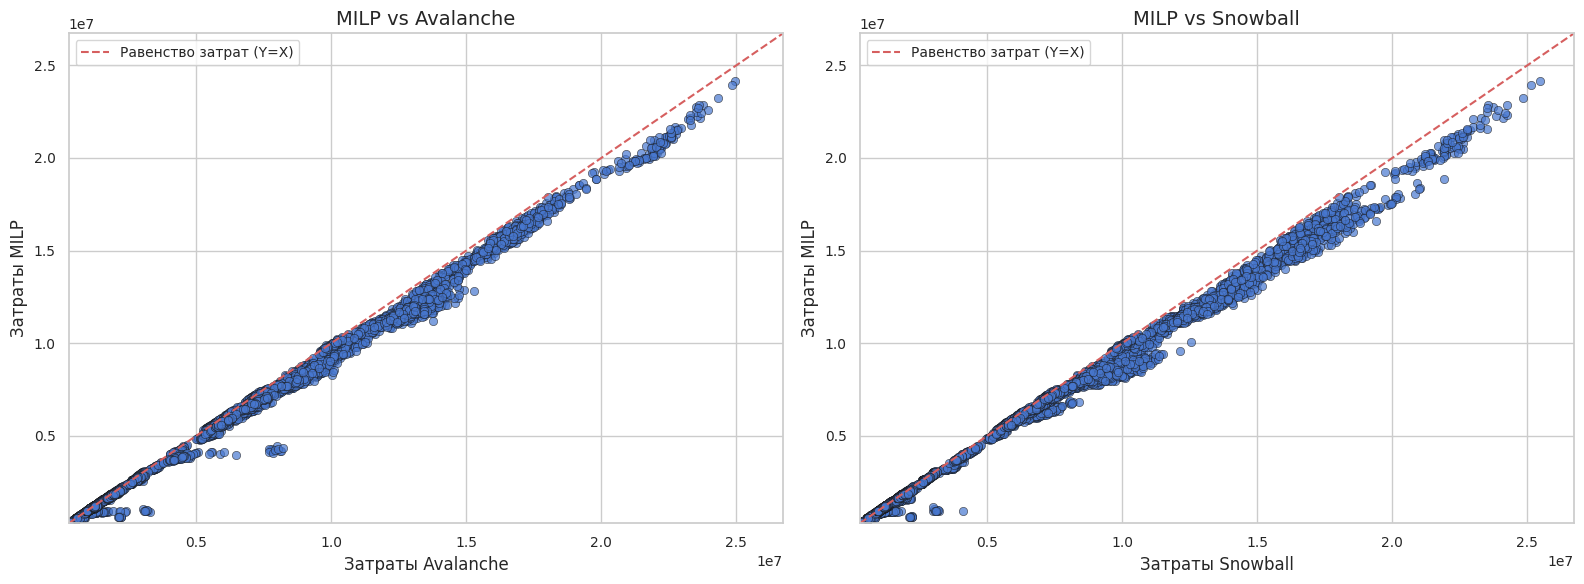

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

max_val = max(df_opt[['milp_cost', 'avalanche_cost', 'snowball_cost']].max()) * 1.05
min_val = min(df_opt[['milp_cost', 'avalanche_cost', 'snowball_cost']].min()) * 0.95

def plot_scatter(ax, x_col, y_col, title, x_label):
    sns.scatterplot(data=df_opt, x=x_col, y=y_col, ax=ax, alpha=0.7, edgecolor='k')
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Равенство затрат (Y=X)')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Затраты MILP")
    ax.legend()
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

plot_scatter(axes[0], 'avalanche_cost', 'milp_cost', 'MILP vs Avalanche', 'Затраты Avalanche')
plot_scatter(axes[1], 'snowball_cost', 'milp_cost', 'MILP vs Snowball', 'Затраты Snowball')

plt.tight_layout()
plt.show()

### 3.2 Распределение разностей (Boxplot и Гистограмма)
Анализ формы распределения $\Delta$ для выбора корректного статистического критерия.

/tmp/ipykernel_27379/3670884681.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['MILP - Avalanche', 'MILP - Snowball'])


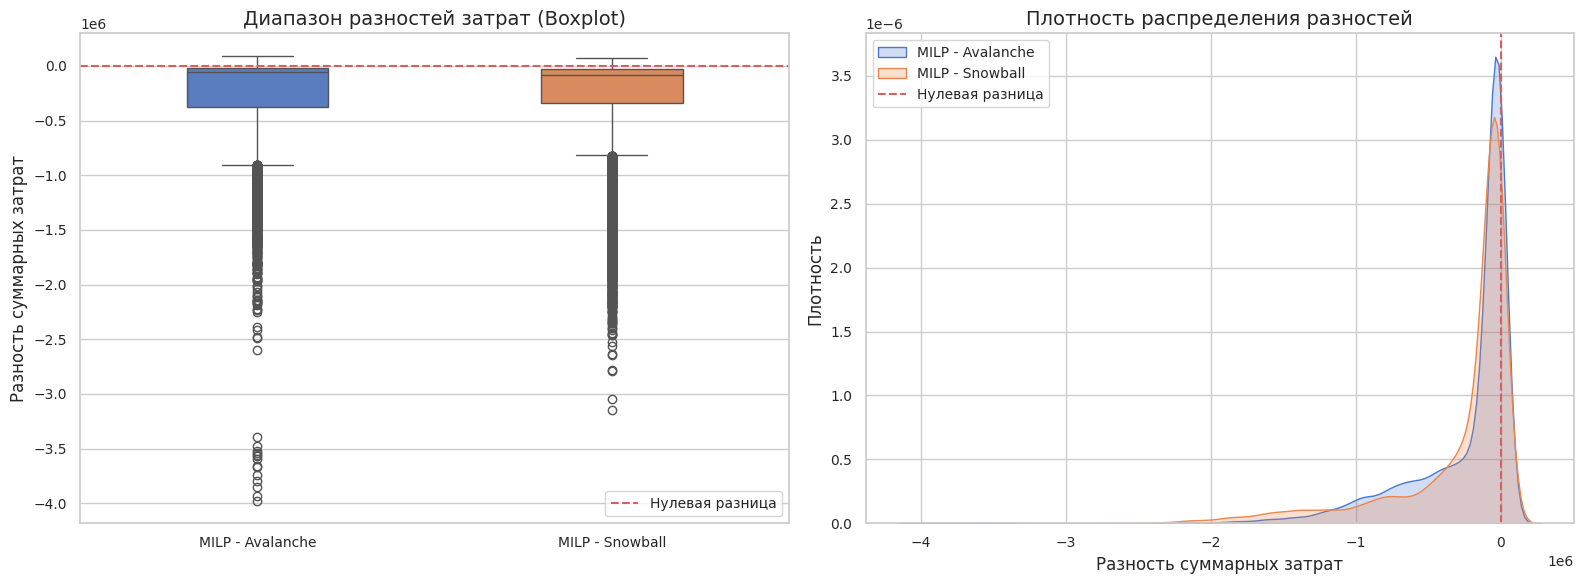

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_opt[['delta_avalanche', 'delta_snowball']], ax=axes[0], width=0.4)
axes[0].axhline(0, color='r', linestyle='--', label='Нулевая разница')
axes[0].set_xticklabels(['MILP - Avalanche', 'MILP - Snowball'])
axes[0].set_ylabel('Разность суммарных затрат')
axes[0].set_title('Диапазон разностей затрат (Boxplot)')
axes[0].legend()

sns.kdeplot(data=df_opt, x='delta_avalanche', ax=axes[1], fill=True, label='MILP - Avalanche')
sns.kdeplot(data=df_opt, x='delta_snowball', ax=axes[1], fill=True, label='MILP - Snowball')
axes[1].axvline(0, color='r', linestyle='--', label='Нулевая разница')
axes[1].set_xlabel('Разность суммарных затрат')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Плотность распределения разностей')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Статистическое тестирование

**Шаг 1. Проверка на нормальность (Критерий Шапиро-Уилка)**

Если $p < 0.05$, распределение значимо отличается от нормального. В таком случае основным критерием становится непараметрический тест Вилкоксона.

**Шаг 2. Односторонний парный тест Вилкоксона**

Проверяет гипотезу о том, что медиана разностей меньше нуля.

**Шаг 3. Односторонний парный t-test**

Применяется как дополнительная проверка устойчивости (robustness check).

In [7]:
def run_statistical_tests(delta_series, name):
    print(f"\n{'='*50}")
    print(f"Анализ для: {name}")
    print(f"{'='*50}")
    
    stat_shapiro, p_shapiro = stats.shapiro(delta_series)
    is_normal = p_shapiro >= 0.05
    print(f"[Шапиро-Уилк] p-value = {p_shapiro:.4e} -> Распределение {'НОРМАЛЬНОЕ' if is_normal else 'НЕ НОРМАЛЬНОЕ'}")
    
    stat_wilcoxon, p_wilcoxon = stats.wilcoxon(delta_series, alternative='less')
    print(f"[Вилкоксон]   p-value = {p_wilcoxon:.4e} -> ", end="")
    if p_wilcoxon < 0.05:
        print("H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.")
    else:
        print("Нет оснований отвергнуть H0.")
        
    stat_ttest, p_ttest = stats.ttest_1samp(delta_series, popmean=0, alternative='less')
    print(f"[t-test]      p-value = {p_ttest:.4e} -> ", end="")
    if p_ttest < 0.05:
        print("H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.")
    else:
        print("Нет оснований отвергнуть H0.")

run_statistical_tests(df_opt['delta_avalanche'], "MILP vs Avalanche")
run_statistical_tests(df_opt['delta_snowball'], "MILP vs Snowball")


Анализ для: MILP vs Avalanche
[Шапиро-Уилк] p-value = 5.9491e-89 -> Распределение НЕ НОРМАЛЬНОЕ
[Вилкоксон]   p-value = 0.0000e+00 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.
[t-test]      p-value = 0.0000e+00 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.

Анализ для: MILP vs Snowball
[Шапиро-Уилк] p-value = 4.6703e-90 -> Распределение НЕ НОРМАЛЬНОЕ
[Вилкоксон]   p-value = 0.0000e+00 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.
[t-test]      p-value = 0.0000e+00 -> H0 ОТВЕРГАЕТСЯ. MILP статистически значимо лучше.


/home/serge/Dev/RPML/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11000.
  res = hypotest_fun_out(*samples, **kwds)


## 5. Выводы

**Статистическая значимость.** 

Тест Вилкоксона и t-test показали статистическую значимость преимуществ MILP-модели над эвристиками.
